In [ ]:
# Install libraries
!pip install tensorflow scikit-learn matplotlib seaborn pillow

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/archive (1).zip" -d /content/
print("Dataset unzipped")

Streaming output truncated to the last 5000 lines.
  inflating: /content/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/Training/glioma/Tr-gl_291.jpg  
  inflating: /content/Training/glioma/Tr-gl_292.jpg  
  inflating: /content/Training/glioma/Tr-gl_293.jpg  
  inflating: /content/Training/glioma/Tr-gl_294.jpg  
  inflating: /content/Training/gl

In [3]:
# Import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print("Libraries imported")
print("GPU:", tf.config.list_physical_devices("GPU"))

Libraries imported
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Settings
IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS     = 3

train_dir = "/content/Training/"
test_dir  = "/content/Testing/"

print("Settings done")
print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Classes:", os.listdir(train_dir))

Settings done
Train dir: /content/Training/
Test dir: /content/Testing/
Classes: ['meningioma', 'pituitary', 'glioma', 'notumor']


In [5]:
# Load dataset
train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 20,
    horizontal_flip  = True,
    brightness_range = [0.8, 1.2],
    zoom_range       = 0.2,
    validation_split = 0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "sparse",
    subset      = "training"
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "sparse",
    subset      = "validation"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size  = BATCH_SIZE,
    class_mode  = "sparse"
)

class_names = list(train_generator.class_indices.keys())

print("Train images:", train_generator.samples)
print("Val images:", val_generator.samples)
print("Test images:", test_generator.samples)
print("Classes:", class_names)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Train images: 4480
Val images: 1120
Test images: 1600
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


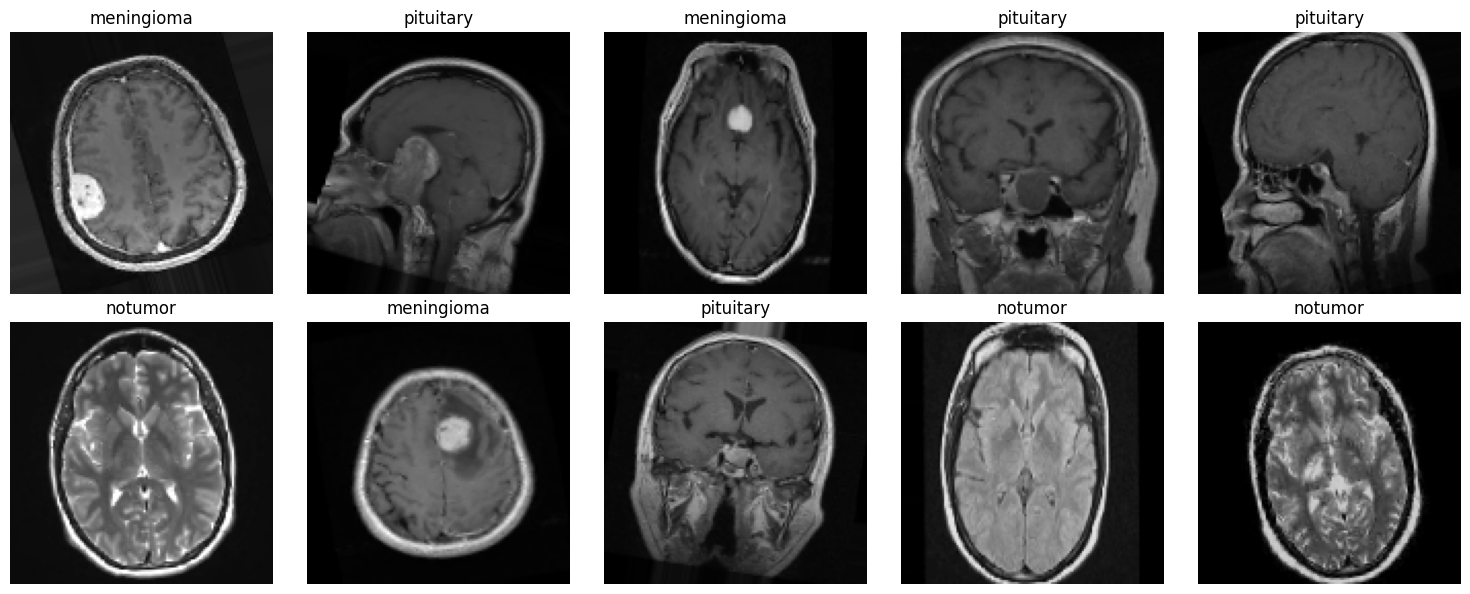

Sample images shown


In [6]:
# Show sample images
images, labels = next(train_generator)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].axis("off")
    axes[i].set_title(class_names[int(labels[i])])
plt.tight_layout()
plt.show()
print("Sample images shown")

In [10]:
# CELL 8 - Build model with VGG16
base_model = VGG16(
    input_shape = (IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top = False,
    weights     = "imagenet"
)

# Unfreeze last 8 layers instead of freezing all
for layer in base_model.layers[:-8]:
    layer.trainable = False
for layer in base_model.layers[-8:]:
    layer.trainable = True

model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.4))
model.add(Dense(256, activation="relu", kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))
model.add(Dense(len(class_names), activation="softmax"))

model.compile(
    optimizer = Adam(learning_rate=0.00001),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)

model.summary()
print("Model built")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,124 (64.14 MB)

 Trainable params: 15,077,636 (57.52 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

Model built


In [11]:
# Train the model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

print("Training started...")

history = model.fit(
    train_generator,
    epochs          = 20,
    validation_data = val_generator,
    callbacks       = callbacks
)

print("Training done")
print("Train Accuracy:", round(history.history["accuracy"][-1] * 100, 2), "%")
print("Val Accuracy:", round(history.history["val_accuracy"][-1] * 100, 2), "%")

Training started...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 303ms/step - accuracy: 0.5931 - loss: 1.4513 - val_accuracy: 0.8179 - val_loss: 0.9236 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 296ms/step - accuracy: 0.8118 - loss: 0.9712 - val_accuracy: 0.8804 - val_loss: 0.7807 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 297ms/step - accuracy: 0.8650 - loss: 0.8292 - val_accuracy: 0.8580 - val_loss: 0.7919 - learning_rate: 1.0000e-05
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 297ms/step - accuracy: 0.8871 - loss: 0.7546 - val_accuracy: 0.9089 - val_loss: 0.6947 - learning_rate: 1.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 298ms/step - accuracy: 0.8933 - loss: 0.7214 - val_accuracy: 0.9161 - val_loss: 0.6656 - learning_rate: 1.0000e-05
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.9047 - loss: 0.6865 - val_accuracy: 0.9304 - val_loss: 0.6356 - learning_rate: 1.0000e-05
Epoch 7/20
140/140 ━━━━━━━

In [13]:
# Evaluate on test data
print("Evaluating on test data...")
results = model.evaluate(test_generator)
print("Test Loss:", round(results[0], 4))
print("Test Accuracy:", round(results[1] * 100, 2), "%")

Evaluating on test data...
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8944 - loss: 0.9660
Test Loss: 0.966
Test Accuracy: 89.44 %


In [14]:
# Classification Report
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.23      0.18      0.21       400
  meningioma       0.23      0.20      0.21       400
     notumor       0.26      0.30      0.28       400
   pituitary       0.26      0.30      0.28       400

    accuracy                           0.25      1600
   macro avg       0.25      0.25      0.24      1600
weighted avg       0.25      0.25      0.24      1600



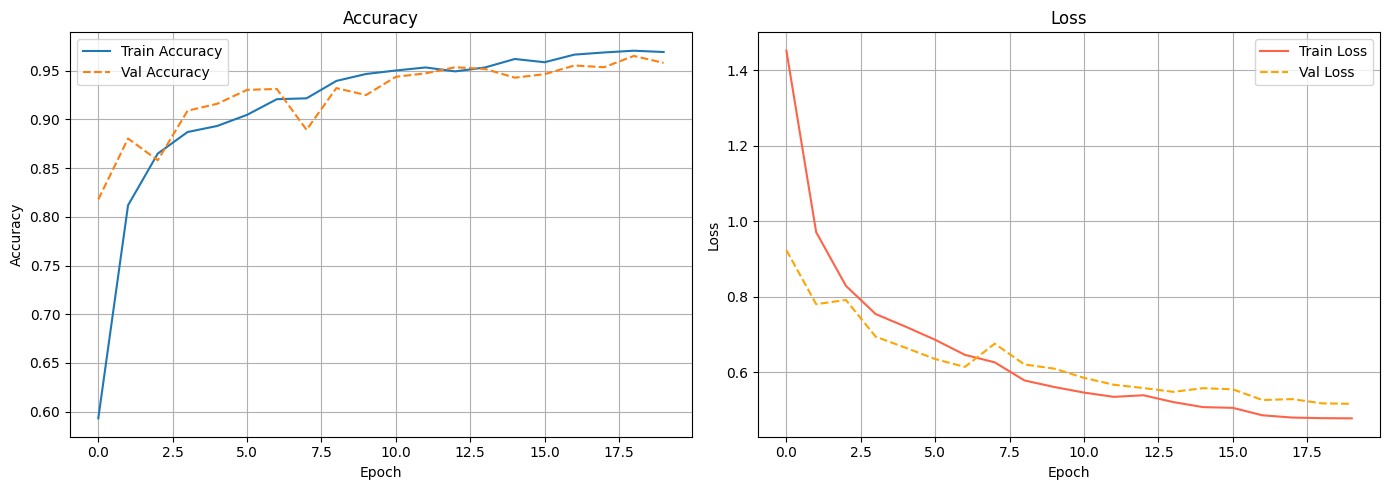

Plots shown


In [15]:
# Plot accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy", linestyle="--")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["loss"],     label="Train Loss",  color="tomato")
axes[1].plot(history.history["val_loss"], label="Val Loss",    color="orange", linestyle="--")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
print("Plots shown")

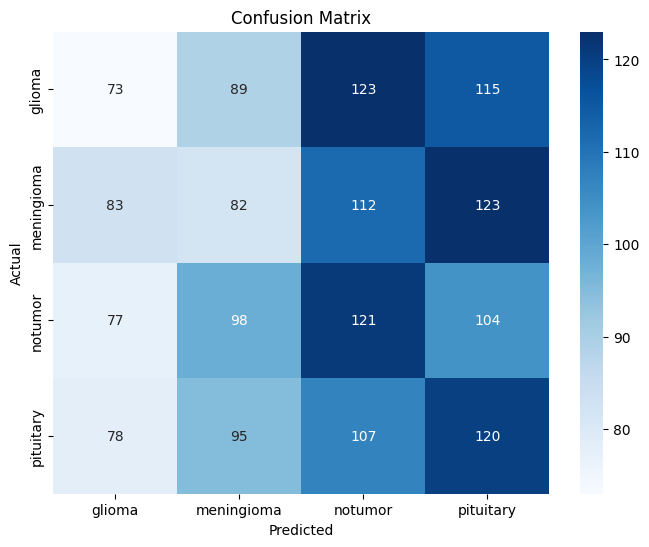

Confusion matrix shown


In [16]:
# CELL 13 - Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Confusion matrix shown")

In [17]:
# CELL 14 - Save model to Google Drive
model.save("/content/drive/MyDrive/brain_tumor_model.h5")
print("Model saved to Google Drive")

Model saved to Google Drive


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


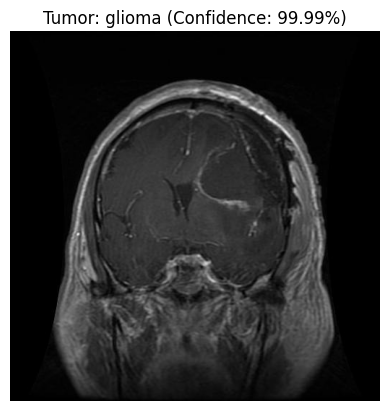

Prediction: Tumor: glioma
Confidence: 99.99 %


In [18]:
# CELL 15 - Predict a single image
def detect_and_display(img_path, model, image_size=128):
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions         = model.predict(img_array)
    predicted_class_idx = np.argmax(predictions, axis=1)[0]
    confidence          = np.max(predictions, axis=1)[0]

    if class_names[predicted_class_idx] == "notumor":
        result = "No Tumor"
    else:
        result = "Tumor: " + class_names[predicted_class_idx]

    plt.imshow(load_img(img_path))
    plt.axis("off")
    plt.title(result + " (Confidence: " + str(round(confidence * 100, 2)) + "%)")
    plt.show()
    print("Prediction:", result)
    print("Confidence:", round(confidence * 100, 2), "%")

# Upload any image to Google Drive and update path below
image_path = "/content/drive/MyDrive/Te-gl_8.jpg"
detect_and_display(image_path, model)